In [28]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image
from typing import TypedDict, Annotated, List, Optional
from pydantic import BaseModel, Field

In [29]:
# Create a graph that classifies bmi category

class BMIState(BaseModel):
    height: float
    weight: float
    bmi: Optional[float]= None
    category: Optional[str]= None

In [30]:
def calculate_bmi(state: BMIState) -> BMIState:
    height= state.height
    weight= state.weight
    
    bmi = weight/(height**2)
    state.bmi= round(bmi, 3) 
    return state 


def categorise_bmi(state: BMIState) -> BMIState:
    bmi= state.bmi 
    
    if bmi < 18.5:
        state.category= 'underweight'
    
    elif bmi >= 18.5 and bmi <= 24.9:
        state.category= 'healthy'
    
    elif bmi > 25 and bmi <= 29.9:
        state.category= 'overweight'
    
    else:
        state.category= 'obese'
        
    return state

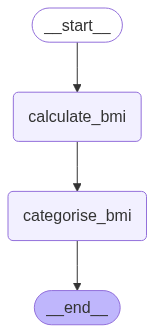

In [33]:
# Create graph object
graph= StateGraph(BMIState)

# Add nodes
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('categorise_bmi', categorise_bmi)

# Add edges
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'categorise_bmi')
graph.add_edge('categorise_bmi', END)

# compile and visualize graph
workflow= graph.compile()
workflow

# Image(workflow.get_graph().draw_png())

In [32]:
# Invoking the graph

initial_state= {
    'weight': 67,
    'height': 1.60
}

final_state= workflow.invoke(initial_state)
print(final_state)

{'height': 1.6, 'weight': 67.0, 'bmi': 26.172, 'category': 'overweight'}
